## ID Forgery Detection System

### Import libraries

In [9]:
!pip install pytesseract

In [19]:
import cv2
import numpy as np
import pytesseract
from PIL import Image
from IPython.display import display
import os

Uploaded Image:


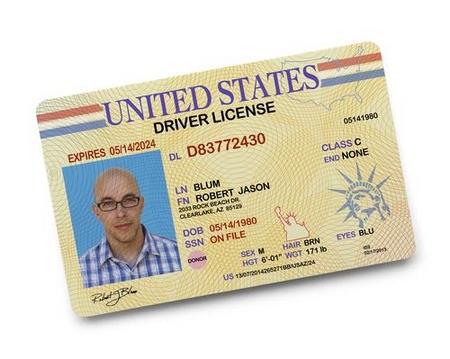

FRAUD DETECTION REPORT
Image path: C:/Users/91623/Downloads/genuine_id.jpg
Blur Score: 2081.924679665738
Extracted Text: 
NER sures
1 eR Sie

cones nite
oy. DEgTIZAT

wn oul
sasott
aoe
po8 nei9e> Se
Ban ONFLE oat :
— ance, Oe
wae eee
woe


Issues Found
None
Final Verdict: Genuine
Confidence Score: 100%


In [41]:
# connect tesseract
pytesseract.pytesseract.tesseract_cmd = r"C:/Program Files/Tesseract-OCR/tesseract.exe"

#load image
image_path = "C:/Users/91623/Downloads/genuine_id.jpg"
if not os.path.exists(image_path):
    print("Image not found. Check path.")
else:
    image = Image.open(image_path)
    print('Uploaded Image:')
    display(image)

#convert image to array
img = np.array(image)

#convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# improve contrast
gray = cv2.bilateralFilter(gray, 11, 17, 17)

# thresholding (important)
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

#check blur(image quality)
blur_value = cv2.Laplacian(gray, cv2.CV_64F).var()

#extract text
text = pytesseract.image_to_string(thresh)

#check for issues
issues = []

if blur_value < 80:
    issues.append('Image is blurry')

if len(text.strip()) == 0:
    issues.append('No text detected')

#final decision
if len(issues) == 0:
    verdict = 'Genuine'
    confidence = f"{round(min(blur_value, 100), 2)}%"
else:
    verdict = 'Suspicious'
    confidence = f"{round(max(50, 100 - blur_value), 2)}%"


#display report
print('FRAUD DETECTION REPORT')

print('Image path:', image_path)
print('Blur Score:', blur_value)

print('Extracted Text: ')
print(text if text.strip() else 'No text found')

print('Issues Found')
if len(issues) == 0:
    print('None')
else:
    for issue in issues:
        print('-',issue)


print('Final Verdict:', verdict)
print('Confidence Score:', confidence)